# 📈 InsuraSight — Notebook 04 : Prévisions Temporelles (Prophet)

Prévision de 3 séries sur 6 mois :
1. Volume mensuel de sinistres
2. Montant total des indemnisations (avec régresseur exogène)
3. Loss Ratio lissé (S/P 3M)

**Méthode** : backtesting sur les 6 derniers mois observés, puis forecast Jan–Jun 2025.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pickle, os, warnings

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
SEED = 42

COLORS = {
    "primary"   : "#1B4F72",
    "secondary" : "#2E86C1",
    "accent"    : "#E74C3C",
    "success"   : "#27AE60",
    "warn"      : "#F39C12",
    "neutral"   : "#5D6D7E",   # gris bleuté
    "light"     : "#D6EAF8",
    "forecast"  : "#8E44AD",
}
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})
print("✅ Imports OK")

✅ Imports OK


## 1. Préparation des séries temporelles

In [3]:
df_sinistres = pd.read_csv("data/raw/sinistres.csv", parse_dates=["date_survenance"])
df_expo      = pd.read_csv("data/raw/exposition_mensuelle.csv")
df_expo["mois_dt"] = pd.to_datetime(df_expo["mois"])
df_sinistres["mois_dt"] = df_sinistres["date_survenance"].dt.to_period("M").dt.to_timestamp()

sin_m = df_sinistres.groupby("mois_dt").agg(
    nb_sinistres=("sinistre_id","count"), montant_indem=("montant_indemnise","sum")).reset_index()
exp_m = df_expo.groupby("mois_dt")["prime_acquise"].sum().reset_index(name="primes")
pol_m = (df_expo[df_expo["statut_police"]=="Active"].groupby("mois_dt")["police_id"]
         .nunique().reset_index(name="nb_polices_actives"))

ts = sin_m.merge(exp_m, on="mois_dt").merge(pol_m, on="mois_dt", how="left").sort_values("mois_dt")
ts = ts.rename(columns={"mois_dt":"ds"})
ts["loss_ratio"] = ts["montant_indem"] / ts["primes"].clip(lower=1)
ts["lr_smooth"]  = (ts["montant_indem"].rolling(3,center=True,min_periods=1).mean() /
                    ts["primes"].rolling(3,center=True,min_periods=1).mean())

HORIZON = 6
cutoff = ts["ds"].max() - pd.DateOffset(months=HORIZON)
ts_train = ts[ts["ds"] <= cutoff].copy()
ts_valid = ts[ts["ds"] >  cutoff].copy()

print(f"Série : {len(ts)} mois ({ts['ds'].min().strftime('%Y-%m')} → {ts['ds'].max().strftime('%Y-%m')})")
print(f"Train : {len(ts_train)} mois | Valid : {len(ts_valid)} mois")
ts[["ds","nb_sinistres","montant_indem","primes","lr_smooth"]].tail()

Série : 48 mois (2021-01 → 2024-12)
Train : 42 mois | Valid : 6 mois


,ds,nb_sinistres,montant_indem,primes,lr_smooth
43,2024-08-01,120,780875,906946.7,0.772961
44,2024-09-01,116,523750,906946.7,0.733261
45,2024-10-01,134,690461,906946.7,0.670584
46,2024-11-01,119,610340,906946.7,0.770974
47,2024-12-01,125,796895,906946.7,0.775809


## 2. Volume mensuel de sinistres

In [4]:
df_vol = ts_train[["ds","nb_sinistres"]].rename(columns={"nb_sinistres":"y"})

m_vol = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode="multiplicative", changepoint_prior_scale=0.05, interval_width=0.90)
m_vol.fit(df_vol)

fut_vol = m_vol.make_future_dataframe(periods=len(ts_valid)+HORIZON, freq="MS")
fc_vol  = m_vol.predict(fut_vol)

obs_v   = ts_valid["nb_sinistres"].values
pred_v  = fc_vol[fc_vol["ds"].isin(ts_valid["ds"])]["yhat"].values
mae_vol = mean_absolute_error(obs_v, pred_v)
base_v  = np.full(HORIZON, ts_train["nb_sinistres"].tail(3).mean())
base_vol= mean_absolute_error(obs_v, base_v)

print(f"Baseline MAE  : {base_vol:.1f}")
print(f"Prophet MAE   : {mae_vol:.1f}")
with open("models/prophet_volume_sinistres.pkl","wb") as f: pickle.dump(m_vol,f)

22:40:13 - cmdstanpy - INFO - Chain [1] start processing
22:40:13 - cmdstanpy - INFO - Chain [1] done processing


Baseline MAE  : 13.0
Prophet MAE   : 28.9


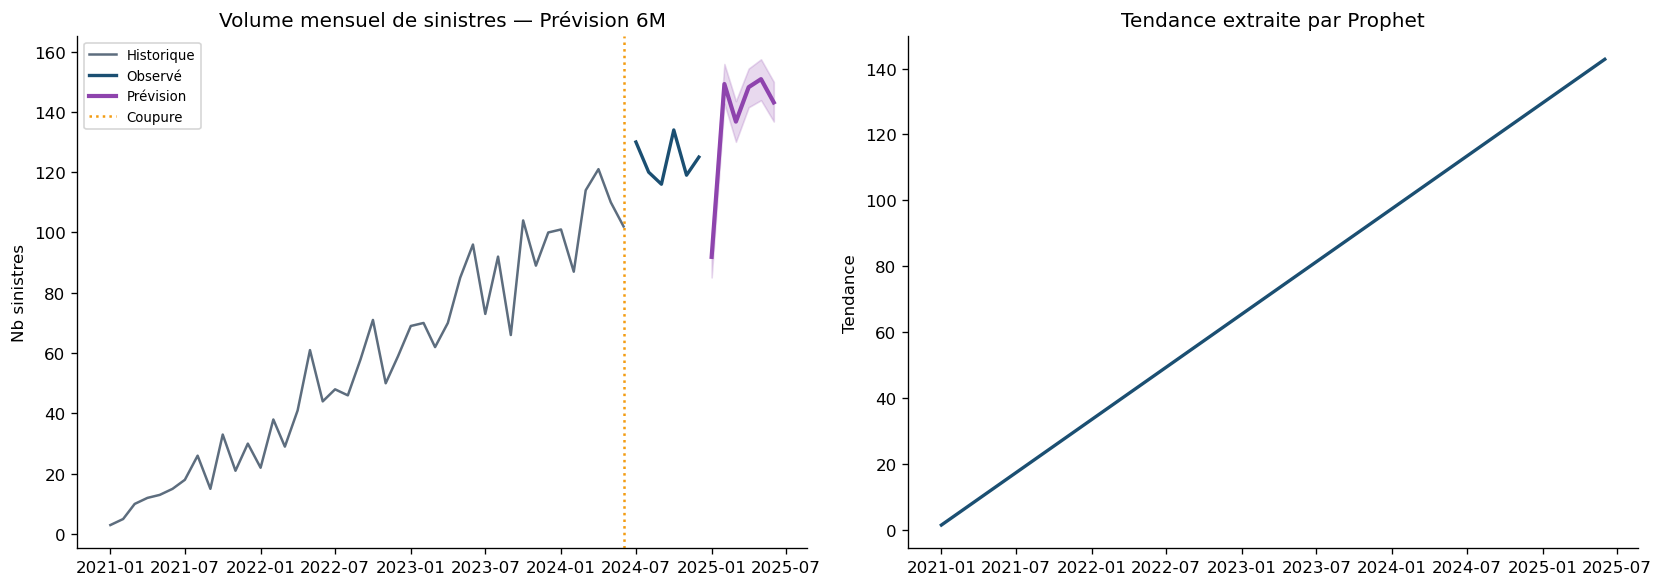

In [5]:
# Visualisation volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Forecast
future_mask = fc_vol["ds"] > ts["ds"].max()
axes[0].plot(ts_train["ds"], ts_train["nb_sinistres"], color=COLORS["neutral"], linewidth=1.5, label="Historique")
axes[0].plot(ts_valid["ds"], ts_valid["nb_sinistres"], color=COLORS["primary"], linewidth=2, label="Observé")
axes[0].plot(fc_vol[future_mask]["ds"], fc_vol[future_mask]["yhat"],
             color=COLORS["forecast"], linewidth=2.5, label="Prévision")
axes[0].fill_between(fc_vol[future_mask]["ds"],
                     fc_vol[future_mask]["yhat_lower"], fc_vol[future_mask]["yhat_upper"],
                     alpha=0.2, color=COLORS["forecast"])
axes[0].axvline(cutoff, color=COLORS["warn"], linestyle=":", linewidth=1.5, label="Coupure")
axes[0].set_title("Volume mensuel de sinistres — Prévision 6M")
axes[0].set_ylabel("Nb sinistres"); axes[0].legend(fontsize=8)

# Composantes
axes[1].plot(fc_vol["ds"], fc_vol["trend"], color=COLORS["primary"], linewidth=2)
axes[1].set_title("Tendance extraite par Prophet")
axes[1].set_ylabel("Tendance")

plt.tight_layout(); plt.show()

## 3. Montant des indemnisations (avec régresseur exogène)

In [6]:
df_mnt = ts_train[["ds","montant_indem","nb_polices_actives"]].rename(columns={"montant_indem":"y"})
df_mnt_v = ts_valid[["ds","montant_indem","nb_polices_actives"]].rename(columns={"montant_indem":"y"})

m_mnt = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode="multiplicative", changepoint_prior_scale=0.1, interval_width=0.90)
m_mnt.add_regressor("nb_polices_actives", standardize=True)
m_mnt.fit(df_mnt.fillna({"nb_polices_actives": df_mnt["nb_polices_actives"].median()}))

fc_mnt_v = m_mnt.predict(df_mnt_v.fillna({"nb_polices_actives": df_mnt_v["nb_polices_actives"].median()}))
mae_mnt  = mean_absolute_error(df_mnt_v["y"].values, fc_mnt_v["yhat"].values)
print(f"Prophet (+ régresseur polices) MAE : {mae_mnt:,.0f} €")
with open("models/prophet_montant_indem.pkl","wb") as f: pickle.dump(m_mnt,f)

22:40:44 - cmdstanpy - INFO - Chain [1] start processing
22:40:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet (+ régresseur polices) MAE : 153,217 €


## 4. Loss Ratio lissé

In [7]:
df_lr = ts_train[["ds","lr_smooth"]].rename(columns={"lr_smooth":"y"})
df_lr_v = ts_valid[["ds","lr_smooth"]].rename(columns={"lr_smooth":"y"})

m_lr = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
               seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.90)
m_lr.fit(df_lr)

fut_lr = m_lr.make_future_dataframe(periods=len(ts_valid)+HORIZON, freq="MS")
fc_lr  = m_lr.predict(fut_lr)
fc_lr["yhat"] = fc_lr["yhat"].clip(lower=0)
fc_lr["yhat_lower"] = fc_lr["yhat_lower"].clip(lower=0)
fc_lr["yhat_upper"] = fc_lr["yhat_upper"].clip(lower=0)

mae_lr = mean_absolute_error(df_lr_v["y"].values,
                              fc_lr[fc_lr["ds"].isin(ts_valid["ds"])]["yhat"].values)
print(f"Prophet Loss Ratio MAE : {mae_lr:.4f}")
with open("models/prophet_loss_ratio.pkl","wb") as f: pickle.dump(m_lr,f)

22:40:57 - cmdstanpy - INFO - Chain [1] start processing
22:40:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet Loss Ratio MAE : 0.1991


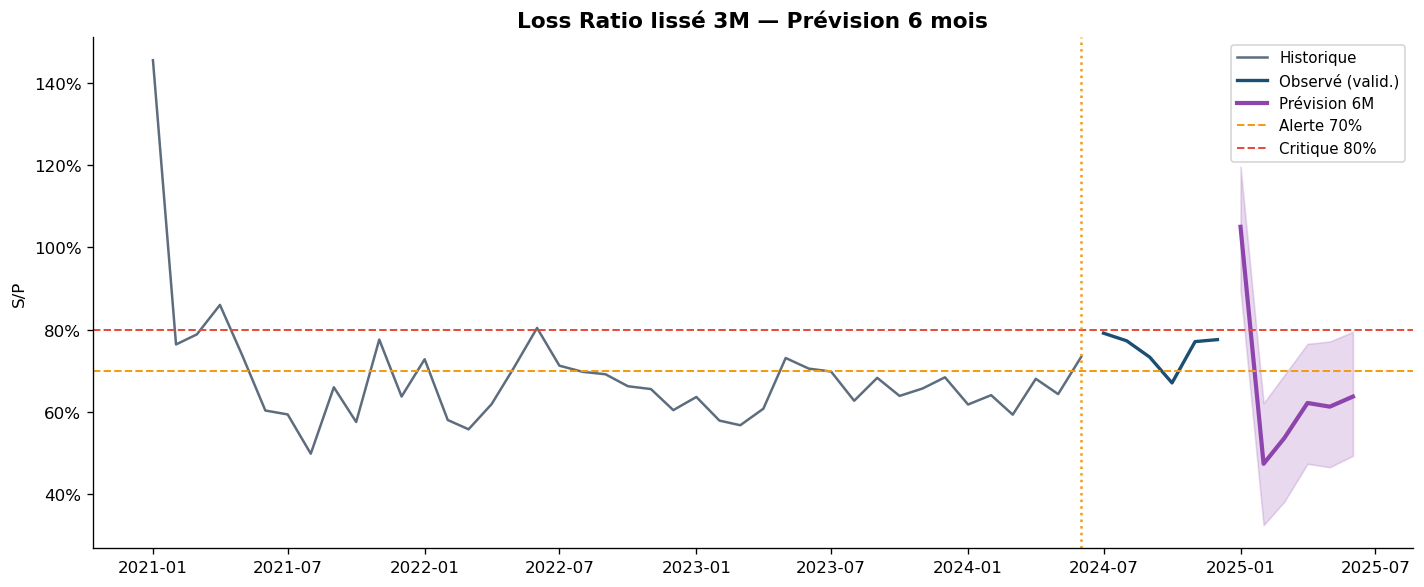


✅ Prévisions terminées — 3 modèles Prophet sauvegardés


In [8]:
# Plot Loss Ratio
fig, ax = plt.subplots(figsize=(12, 5))

future_mask_lr = fc_lr["ds"] > ts["ds"].max()
ax.plot(ts_train["ds"], ts_train["lr_smooth"], color=COLORS["neutral"], linewidth=1.5, label="Historique")
ax.plot(ts_valid["ds"], ts_valid["lr_smooth"], color=COLORS["primary"], linewidth=2, label="Observé (valid.)")
ax.plot(fc_lr[future_mask_lr]["ds"], fc_lr[future_mask_lr]["yhat"],
        color=COLORS["forecast"], linewidth=2.5, label="Prévision 6M")
ax.fill_between(fc_lr[future_mask_lr]["ds"],
                fc_lr[future_mask_lr]["yhat_lower"], fc_lr[future_mask_lr]["yhat_upper"],
                alpha=0.2, color=COLORS["forecast"])
ax.axhline(0.70, color=COLORS["warn"],  linestyle="--", linewidth=1.2, label="Alerte 70%")
ax.axhline(0.80, color=COLORS["accent"],linestyle="--", linewidth=1.2, label="Critique 80%")
ax.axvline(cutoff, color=COLORS["warn"], linestyle=":", linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax.set_title("Loss Ratio lissé 3M — Prévision 6 mois", fontsize=13, fontweight="bold")
ax.set_ylabel("S/P"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("\n✅ Prévisions terminées — 3 modèles Prophet sauvegardés")